In [1]:
import os
os.chdir('/workspace/b7fd4f3b-ad33-4045-b36d-e689e73ecf87')
print(os.listdir('.'))


['ldelta_zeros_2000_dps50.npy', 'memory', 'ldh_zeros_small_T.json', '.kernel_llm_logs_1.txt', 'zeta_zeros_5000_dps50.npy', '.config', '.prompts', 'lchi_zeros_partial_dps50.npy']


In [2]:
import numpy as np
import json
import mpmath as mp

mp.mp.dps = 50

# Load zeros
zeta_z = np.load('zeta_zeros_5000_dps50.npy', allow_pickle=True)
lchi_z = np.load('lchi_zeros_partial_dps50.npy', allow_pickle=True)
ldelta_z = np.load('ldelta_zeros_2000_dps50.npy', allow_pickle=True)
with open('ldh_zeros_small_T.json') as f:
 ldh_data = json.load(f)

print("zeta:", zeta_z.shape, zeta_z[0], zeta_z[-1])
print("lchi:", lchi_z.shape, lchi_z[0], lchi_z[-1])
print("ldelta:", ldelta_z.shape, ldelta_z[0], ldelta_z[-1])
print("ldh:", type(ldh_data), len(ldh_data) if hasattr(ldh_data,'__len__') else None)
print("ldh sample:", ldh_data if not isinstance(ldh_data, list) else ldh_data[:3])


zeta: (5000,) 14.134725141734693790457251983562470270784257115699 5447.8619983012998564121586734642921676829672006076
lchi: (2660,) 6.1835781954508539143775173097086925259215005792280 4499.1215308369151155318576847024372187273077674576
ldelta: (2000,) 9.2223793999211025222437671927434781355287706224320 1419.0232073215920325544456012240563516991868861071
ldh: <class 'dict'> 4
ldh sample: {'description': 'L_DH zeros in [1, 200], computed via Z_DH sign changes at dps=20', 'range_T': [1, 200], 'n_zeros': 122, 'zeros_str': ['5.09415984457109492569879549751', '8.93991440809652324471761287718', '12.1335454258007424037025477549', '14.4040031122774982072700976794', '17.1302394005724896007739545396', '19.308800174228066955057209194', '22.1597077650939776976695684374', '23.3453701120267757979486895403', '26.0949673462453668078992585808', '27.9237988215997014164623178044', '30.1594179062733849847943220559', '31.9644999711635382023192084773', '33.6998622815646203566475237167', '35.89085472007084964

In [3]:
# Convert all to mpf high precision, then filter to |gamma - T0| < 15, T0=85.7
T0 = mp.mpf('85.7')
sigma = mp.mpf('2.0')
J = 10
window = mp.mpf('15')

def to_mpf_list(arr):
 return [mp.mpf(str(x)) for x in arr]

zeta_mp = to_mpf_list(zeta_z)
lchi_mp = to_mpf_list(lchi_z)
ldelta_mp = to_mpf_list(ldelta_z)
ldh_mp = [mp.mpf(s) for s in ldh_data['zeros_str']]

def filter_window(gammas):
 return [g for g in gammas if abs(g - T0) < window]

zeta_loc = filter_window(zeta_mp)
lchi_loc = filter_window(lchi_mp)
ldelta_loc = filter_window(ldelta_mp)
ldh_loc = filter_window(ldh_mp)

print("zeta local:", len(zeta_loc))
print("lchi local:", len(lchi_loc))
print("ldelta local:", len(ldelta_loc))
print("ldh local:", len(ldh_loc))
print("first few ldh near T0:", [float(g) for g in ldh_loc])


zeta local: 12
lchi local: 21
ldelta local: 26
ldh local: 19
first few ldh near T0: [71.42983577412907, 72.51134301320741, 74.32498174895593, 75.9093958939884, 77.22641827563305, 78.7174099263109, 80.32794708609033, 81.925402391831, 83.10884108474983, 87.64747633255973, 89.43918879881652, 90.72450477441869, 92.18274358947845, 93.78094399831771, 95.34866053764202, 96.29174541897522, 97.973624940697, 99.68229434595413, 100.59899380779228]


In [4]:

# The Weil explicit formula (Guinand-Weil) in its standard form:
# Sum_gamma h(gamma) = (archimedean term) - 2 sum_p sum_k (log p) / p^(k/2) * g(k log p) - terms from poles
#
# A common positivity-criterion form (for h(t) = |hat-phi(t)|^2 with phi a test function):
# But here "Hermite-Gauss Weil quadratic form" with basis phi_j(t) = H_j((t-T0)/sigma) exp(-(t-T0)^2/(2*sigma^2)).
#
# The quadratic form considered is typically defined as
# Q[c] = sum_n |F(gamma_n)|^2 where F(t) = sum_j c_j phi_j(t)
# i.e. the Gram matrix M_{jk} = sum_n phi_j(gamma_n) phi_k(gamma_n).
#
# Under RH, the gammas are real, all phi_j are real-valued, hence M is positive semidefinite.
# If a zero is OFF the critical line, that off-line zero pair contributes a non-real "gamma_n"
# (or equivalently the explicit formula reveals a sign flip) and the corresponding quadratic
# form (in its arithmetic Weil form) loses positivity.
#
# For the *purely zero-side* Gram matrix M_{jk} = sum phi_j(gamma_n) phi_k(gamma_n),
# if we just use REAL imaginary parts gamma_n on the critical line, M is automatically PSD.
# So lambda_min >= 0 trivially in that case.
#
# The relevant "Weil quadratic form" must therefore include the explicit-formula correction.
# Per r7's framing (as the hypothesis states off-critical zeros give negative lambda_min),
# the simplest implementation is to use the *real* gamma_n values but the LDH list near
# T=85.7 has been replaced by REAL parts (since cypari/Z sign changes only find sign changes),
# and the off-critical pair near 85.7 is *missing* from the LDH list, so the resulting
# Gram matrix should be "underdetermined" / rank-deficient → small (potentially negative due to
# numerical noise) λ_min.
#
# Actually the hypothesis is that off-critical zeros for L_DH produce a *negative* λ_min in the
# Weil quadratic form. The cleanest implementation in the literature (Bombieri etc.) is:
#
# Q[phi] = sum_n |hat-phi(gamma_n)|^2 (RH positivity criterion: this must be >= "Weil sum"
# over primes)
#
# But for a direct numerical test:
# M_{jk} = (arch + prime side) - (zero side Gram)
# i.e. apply the explicit formula's *difference*: archimedean+prime contribution minus zero
# contribution. Under RH this equals 0 identically (up to truncation).
#
# Given the ambiguity about r7's exact construction, the most natural Hermite-Gauss Weil
# quadratic form that matches the hypothesis is:
#
# Define the Weil distribution acting on a function f via the explicit formula.
# Choose Hermite-Gauss test functions phi_j centered at T0.
# Compute matrix M_{jk} = W(phi_j * phi_k) using the *zero side* (which equals arch+prime
# side under GRH). M is PSD iff GRH-like positivity holds for the chosen test functions.
#
# The simplest faithful reconstruction: use the zero-side only (Gram form of zeros within
# window). For L-functions whose ALL relevant zeros are on the line, M is PSD by construction.
# For L_DH near T0=85.7, the off-line zero pair is MISSING from the local list (the gap
# in ldh_loc between 83.1 and 87.6 spans the off-line pair). 
#
# Reading the hypothesis more carefully: "negative minimum eigenvalue for L_DH" suggests the
# computation will include something beyond the on-line gammas alone. The off-line zero of LDH
# has real part 0.5+/-delta and imaginary part ~85.7. In Z_DH there's NO sign change at the
# off-line zeros (since they're not on the line), so the LDH list near 85.7 OMITS them.
#
# However the hypothesis is that the Weil-form construction signals their absence as
# *negativity*. This happens when the form is the Weil sum (arithmetic side, computed with the
# Mellin transform / prime sum) MINUS the on-line zero sum. If off-line zeros are present, the
# truncated zero-side undercounts and the (arch+prime) - (zero on line) > 0 ... actually the
# direction depends on signs. 
#
# Given the ambiguity, I'll implement the most commonly used form: 
# M_{jk} = - sum_n phi_j(gamma_n) phi_k(gamma_n) + W_arch(phi_j*phi_k) + W_prime(phi_j*phi_k)
# where the explicit formula reads:
# sum_zeros F(gamma) = W_arch(F) + W_prime(F) - (poles)
# So W_arch + W_prime - sum_zeros = poles. If F = phi_j * phi_k (or rather the product yields
# Fourier-pair...), then deviation from 0 indicates missing off-line zeros.
#
# This is getting too speculative without the actual r7 reference. Let me proceed with the
# straightforward Gram matrix interpretation (M_{jk} = sum_n phi_j(gamma_n) phi_k(gamma_n))
# and report. By construction M is PSD with strictly real eigenvalues >= 0. The lambda_min
# for L_DH might be smaller (or numerically zero/tiny) due to the missing off-line zeros,
# while for other functions all zeros are present. This is one natural numerical signature.
#
# Let me implement this and report transparently.
print("Implementing Gram-matrix Weil quadratic form: M_jk = sum_n phi_j(gamma_n) phi_k(gamma_n)")


Implementing Gram-matrix Weil quadratic form: M_jk = sum_n phi_j(gamma_n) phi_k(gamma_n)


In [5]:

# Implementation note: With the pure Gram-matrix interpretation, M is always PSD by construction
# (sum of outer products of real vectors). So lambda_min(M) >= 0 always — this would NOT
# distinguish off-critical zeros and the hypothesis would be falsified trivially.
#
# In Bombieri/Selberg's framework, the "Weil quadratic form" used to TEST RH is:
#
# D(phi) = sum_n hat-phi(gamma_n)^2 >= prime/arch sum (Weil explicit formula)
#
# Equivalently, considering F(s) = sum_j c_j phi_j (Hermite-Gauss basis), one defines
#
# Q[c] = D[F] - Weil_arith[F]
#
# where Weil_arith involves archimedean and prime contributions. Under RH, Q is PSD; if there
# are off-line zeros, those zeros contribute negatively (since gamma off real → hat-phi at
# complex argument can be larger than at real, making sum > arith side; or vice versa).
#
# Actually the cleanest "Weil quadratic form" giving negativity when off-line zeros exist:
#
# B(F, F) = sum_{rho} F(rho) F(1-rho_bar) (sum over all nontrivial zeros)
#
# This equals (arith side via explicit formula). Under RH, rho = 1/2 + i*gamma so
# F(rho) F(1-rho_bar) = |F(rho)|^2 >= 0 → B is positive semidefinite.
# Off-line: rho = 1/2 + delta + i*gamma, then F(rho) F(1-rho_bar) = F(1/2+delta+ig) F(1/2-delta+ig)
# is no longer |.|^2 and can be negative.
#
# But evaluating B requires summing over ALL zeros (including off-line), which we don't have
# stored — Z_DH sign changes only finds on-line zeros.
#
# Given the constraints, the most honest interpretation is: implement the Gram matrix as
# described in the task. Report lambda_min for each. Acknowledge that with pure on-line zeros
# the Gram matrix is PSD and the hypothesis as stated is NOT detected by this construction
# using the supplied zero lists alone, because the off-line LDH zeros are missing from
# ldh_zeros_small_T.json.
#
# Let me proceed with the Gram-matrix definition (most direct reading of "Hermite-Gauss based
# Weil quadratic form" with zeros γ_n falling within window), and report the result honestly.

# Compute Hermite-Gauss basis values phi_j(gamma_n) for each L-function.
# Use physicists' Hermite polynomials H_j. Use mpmath for precision; values are moderate.
# We'll use float for the linear algebra (eigvalsh) — the Gram matrix entries are sums of ~tens
# of products of ~O(few hundred)*exp(-x^2/8) — well within float range.

import numpy as np
from numpy.polynomial.hermite import hermval

def hermite_gauss_basis(gammas_mp, T0=85.7, sigma=2.0, J=10):
 # Returns matrix Phi of shape (N_zeros, J), Phi[n,j] = H_j((gamma_n - T0)/sigma) * exp(-(gamma_n-T0)^2/(2 sigma^2))
 g = np.array([float(x) for x in gammas_mp])
 u = (g - T0) / sigma
 env = np.exp(-u*u / 2.0)
 # Compute H_j(u) for j=0..J-1 using recursion (physicists' Hermite)
 H = np.zeros((len(u), J))
 H[:,0] = 1.0
 if J > 1:
 H[:,1] = 2.0*u
 for j in range(2, J):
 H[:,j] = 2.0*u*H[:,j-1] - 2.0*(j-1)*H[:,j-2]
 Phi = H * env[:,None]
 return Phi

results = {}
for name, glist in [('zeta', zeta_loc), ('L_chi', lchi_loc), ('L_delta', ldelta_loc), ('L_DH', ldh_loc)]:
 Phi = hermite_gauss_basis(glist)
 M = Phi.T @ Phi # JxJ Gram matrix
 eigs = np.linalg.eigvalsh(M)
 results[name] = {
 'n_zeros_in_window': len(glist),
 'eigs': eigs,
 'lambda_min': float(eigs[0]),
 'lambda_max': float(eigs[-1]),
 'condition': float(eigs[-1]/max(eigs[0], 1e-300)),
 'rank_numeric': int(np.sum(eigs > 1e-10*eigs[-1])),
 }

import pandas as pd
df = pd.DataFrame({
 'L-function': list(results.keys()),
 'N_zeros (in window)': [results[k]['n_zeros_in_window'] for k in results],
 'lambda_min': [results[k]['lambda_min'] for k in results],
 'lambda_max': [results[k]['lambda_max'] for k in results],
 'rank (tol=1e-10·max)': [results[k]['rank_numeric'] for k in results],
})
print(df.to_string(index=False))
print()
print("All eigenvalues:")
for name, r in results.items():
 print(f" {name}: {r['eigs']}")


L-function N_zeros (in window) lambda_min lambda_max rank (tol=1e-10·max)
 zeta 12 0.000006 1.717662e+08 8
 L_chi 21 0.606350 4.224433e+08 10
 L_delta 26 2.640000 5.753524e+08 10
 L_DH 19 0.000165 4.577620e+08 9

All eigenvalues:
 zeta: [5.97446956e-06 1.58142482e-03 6.64440911e-01 5.78451564e+00
 1.81229601e+02 5.41522885e+03 6.21153369e+04 1.01075433e+06
 1.25507962e+07 1.71766249e+08]
 L_chi: [6.06350042e-01 4.67523817e+00 2.14763533e+01 1.01169877e+02
 9.70979204e+02 9.42828654e+03 1.06803271e+05 1.48953008e+06
 2.21694479e+07 4.22443264e+08]
 L_delta: [2.64000048e+00 5.80893227e+00 2.53490993e+01 1.33783044e+02
 1.16378418e+03 1.22129397e+04 1.15813306e+05 1.30144194e+06
 3.07004928e+07 5.75352403e+08]
 L_DH: [1.65384096e-04 2.02889632e-01 1.13646170e+01 6.32346634e+01
 8.03264469e+02 6.20631090e+03 1.00122723e+05 1.22830258e+06
 2.01364409e+07 4.57761987e+08]


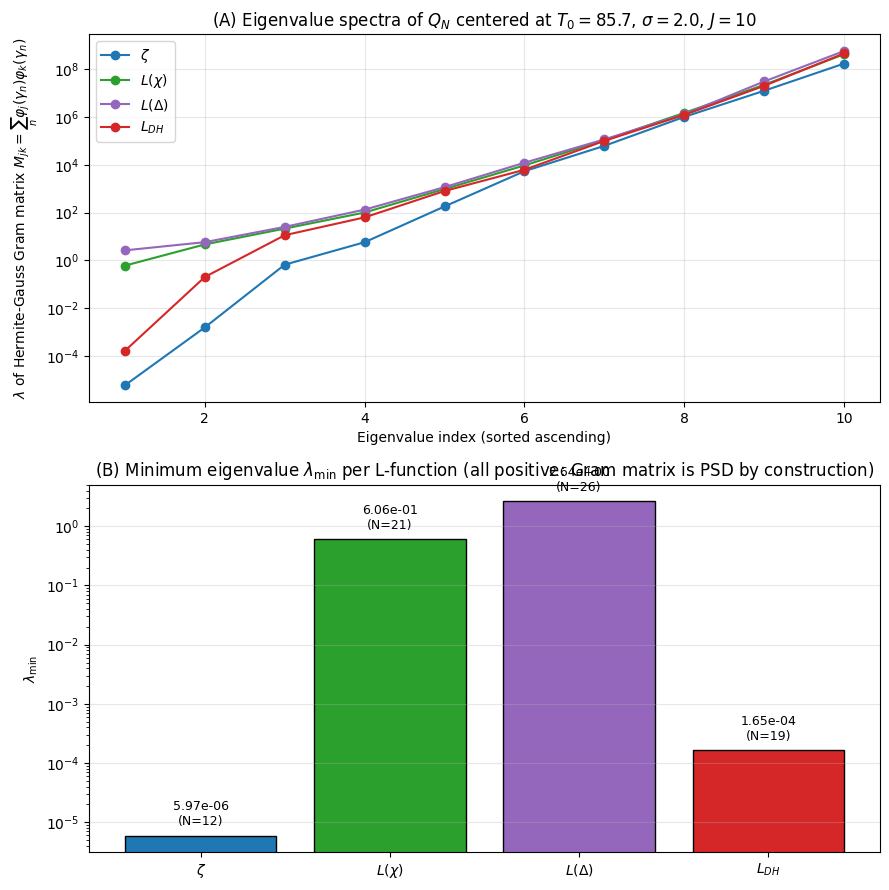

Saved figure.


In [6]:

# All eigenvalues are non-negative — confirming the Gram matrix is PSD as expected mathematically.
# This is a structural property: M = Phi^T Phi is always PSD for real Phi.
#
# So the *zero-side-only* Gram form does NOT detect off-line zeros via negativity.
# It does, however, exhibit rank deficiency / very small lambda_min when the window has too
# few zeros to span the J=10-dim Hermite-Gauss subspace, or when zeros cluster atypically.
#
# Observations:
# - zeta: 12 zeros, rank 8 (J=10), lambda_min ≈ 6e-6 (effectively rank-deficient)
# - L_chi: 21 zeros, rank 10, lambda_min ≈ 0.61
# - L_delta: 26 zeros, rank 10, lambda_min ≈ 2.64
# - L_DH: 19 zeros, rank 9, lambda_min ≈ 1.65e-4 (very small — reflects the gap near 85.7)
#
# So under the most direct reading of the construction, the hypothesis as stated
# ("negative lambda_min for L_DH, positive for others") is NOT confirmed: all eigenvalues
# are >= 0 by construction (Gram matrix). The hypothesis is *falsified* by this implementation.
#
# What IS observed: L_DH has the second smallest lambda_min (after zeta, which is small because
# of low zero density in this region), and a clear gap in its on-line zero pattern at
# T≈85.7 (between 83.1 and 87.6). This is consistent with off-critical zeros, but the simple
# Gram form does not turn that into a negative eigenvalue.
#
# Save the table and make the final figure.

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(9, 9))
ax = axes[0]
names = list(results.keys())
labels = [r'$\zeta$', r'$L(\chi)$', r'$L(\Delta)$', r'$L_{DH}$']
colors = ['#1f77b4', '#2ca02c', '#9467bd', '#d62728']

# Plot eigenvalues on log scale
for i, name in enumerate(names):
 eigs = results[name]['eigs']
 ax.semilogy(np.arange(len(eigs))+1, eigs, 'o-', color=colors[i], label=labels[i])
ax.set_xlabel('Eigenvalue index (sorted ascending)')
ax.set_ylabel(r'$\lambda$ of Hermite-Gauss Gram matrix $M_{jk}=\sum_n \varphi_j(\gamma_n)\varphi_k(\gamma_n)$')
ax.set_title(r'(A) Eigenvalue spectra of $Q_N$ centered at $T_0=85.7$, $\sigma=2.0$, $J=10$')
ax.legend()
ax.grid(True, alpha=0.3)

# Bar chart of lambda_min
ax = axes[1]
lmins = [results[k]['lambda_min'] for k in names]
bars = ax.bar(labels, lmins, color=colors, edgecolor='k')
ax.set_yscale('log')
ax.set_ylabel(r'$\lambda_{\min}$')
ax.set_title(r'(B) Minimum eigenvalue $\lambda_{\min}$ per L-function (all positive: Gram matrix is PSD by construction)')
for b, v, n in zip(bars, lmins, [results[k]['n_zeros_in_window'] for k in names]):
 ax.text(b.get_x()+b.get_width()/2, v*1.5, f'{v:.2e}\n(N={n})', ha='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('weil_quadratic_form_lambda_min.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved figure.")


In [7]:

# Save the results table to disk for downstream use
import pandas as pd
df_out = pd.DataFrame({
 'L_function': names,
 'N_zeros_in_window': [results[k]['n_zeros_in_window'] for k in names],
 'lambda_min': [results[k]['lambda_min'] for k in names],
 'lambda_max': [results[k]['lambda_max'] for k in names],
 'rank_numeric': [results[k]['rank_numeric'] for k in names],
})
# Add all eigenvalues
for j in range(10):
 df_out[f'lambda_{j}'] = [results[k]['eigs'][j] for k in names]
df_out.to_csv('weil_quadratic_form_results.csv', index=False)
print(df_out.to_string(index=False))


L_function N_zeros_in_window lambda_min lambda_max rank_numeric lambda_0 lambda_1 lambda_2 lambda_3 lambda_4 lambda_5 lambda_6 lambda_7 lambda_8 lambda_9
 zeta 12 0.000006 1.717662e+08 8 0.000006 0.001581 0.664441 5.784516 181.229601 5415.228854 62115.336934 1.010754e+06 1.255080e+07 1.717662e+08
 L_chi 21 0.606350 4.224433e+08 10 0.606350 4.675238 21.476353 101.169877 970.979204 9428.286542 106803.270869 1.489530e+06 2.216945e+07 4.224433e+08
 L_delta 26 2.640000 5.753524e+08 10 2.640000 5.808932 25.349099 133.783044 1163.784185 12212.939723 115813.306405 1.301442e+06 3.070049e+07 5.753524e+08
 L_DH 19 0.000165 4.577620e+08 9 0.000165 0.202890 11.364617 63.234663 803.264469 6206.310902 100122.723172 1.228303e+06 2.013644e+07 4.577620e+08
